Dataset Shape: (11162, 17)
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

Best Parameters Found: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

Accura

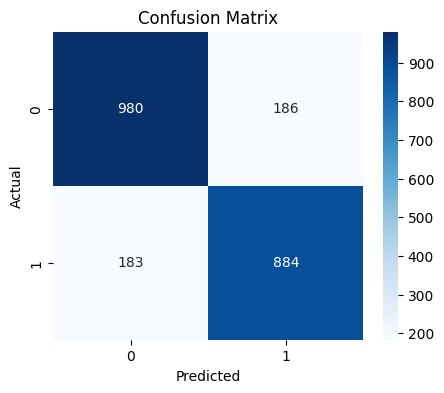


Experiment Completed Successfully ✅


In [10]:
# ============================
# EXPERIMENT 5 - SVM CLASSIFICATION WITH HYPERPARAMETER TUNING
# Dataset: Bank Marketing (deposit version)
# ============================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------------------
# 1. Load Dataset (Correct Way)
# ----------------------------
df = pd.read_csv("bank.csv")   # removed sep=";"
print("Dataset Shape:", df.shape)
print(df.head())

# ----------------------------
# 2. Preprocessing
# ----------------------------

# Convert target variable to binary
df['deposit'] = df['deposit'].map({'yes':1, 'no':0})

# One-hot encoding for categorical variables
df = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df.drop("deposit", axis=1)
y = df["deposit"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ----------------------------
# 3. SVM + Hyperparameter Tuning
# ----------------------------

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01]
}

grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("\nBest Parameters Found:", grid.best_params_)

best_model = grid.best_estimator_

# ----------------------------
# 4. Evaluation
# ----------------------------

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nExperiment Completed Successfully ✅")

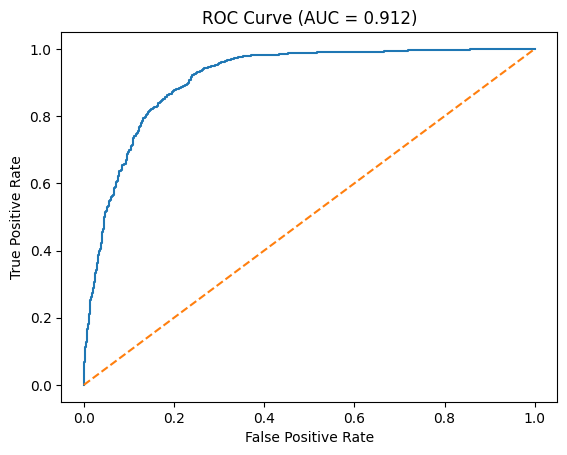

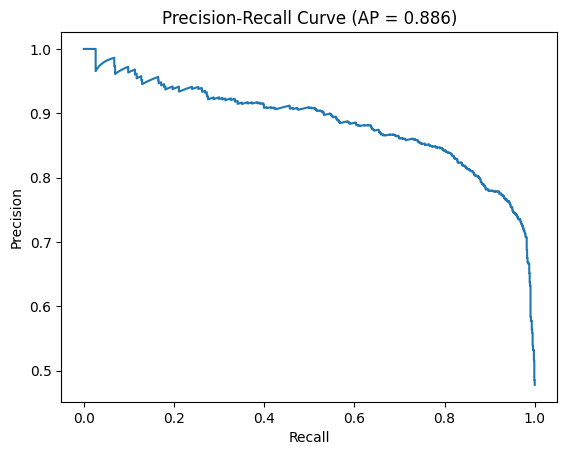

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Get decision scores
y_scores = best_model.decision_function(X_test)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()